# St-Patricks-Day -- a quantitative teardown
### 99 sessions * ^GSPC daily * HAC Newey-West * placebo * Bonferroni * sub-period split

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We test the St. Patrick's Day bump on ^GSPC daily returns with a HAC (Newey-West) t-stat on the event-day mean, a Welch contrast against all other days and against other March days, a March-24 placebo, a Bonferroni-corrected day-of-March sweep, a sub-period split, and a synthetic positive control.

> **Not investment advice.** Real data: ^GSPC daily close (price-only log-returns, 1928--2026) from the shared `_cache/^GSPC_split_only.parquet`; St. Patrick sessions derived by date arithmetic in `data.py`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship:** none -- ^GSPC is an index, not a survivor-selected basket. **Returns are price-only** (no dividends); a total-return tape would lift *every* day equally and not change the contrast.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from st_patricks_day import data, strategy as st

def _have_cache():
    try:
        data.fetch_gspc(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = {'fp': 'df3897aef897', 'year_start': 1928, 'year_end': 2026, 'n_days': 24728, 'n_stpat': 99, 'mean_stpat_bps': 14.8, 'tstat_stpat_hac': 1.13, 'mean_all_bps': 2.4, 'contrast_vs_all_bps': 12.4, 'tstat_welch_all': 0.93, 'pval_welch_all': 0.353, 'mean_march_other_bps': 0.7, 'contrast_vs_march_bps': 14.1, 'tstat_welch_march': 1.04, 'pval_welch_march': 0.299, 'n_placebo': 99, 'mean_placebo_bps': 3.5, 'pval_placebo_march': 0.877, 'pval_bonferroni_17': 1.0, 'sub_a_lbl': '1928-1960', 'sub_a_n': 33, 'sub_a_bps': -9.9, 'sub_a_t': -0.43, 'sub_b_lbl': '1961-1990', 'sub_b_n': 30, 'sub_b_bps': -12.2, 'sub_b_t': -0.89, 'sub_c_lbl': '1991-2026', 'sub_c_n': 36, 'sub_c_bps': 59.9, 'sub_c_t': 3.27, 'net_mean_bps': 12.8, 'net_tstat_hac': 0.98, 'strat_per_event_pct': 0.128, 'mc_31': (67, -24.8, 0.107), 'mc_10': (99, 23.1, 0.265), 'mc_17': (99, 14.8, 0.299), 'mc_03': (99, 8.6, 0.433), 'mc_24': (99, 3.5, 0.877)}

from scipy import stats as scipy_stats


GSPC cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | St. Patrick mean **+14.8 bps**, HAC t = **1.13**; vs other March days Welch p = **0.299**. |
| **Tradability** | `MIRAGE` | One round-trip/yr, ~13 bps net, HAC t = **0.98**; dominated by holding the index. |
| **Busted?** | `YES` | Effect is +60 bps post-1990, *negative* pre-1990; placebo (Mar 24) flat; nothing survives Bonferroni. |

> The unconditional drift and a single lucky modern regime do all the work. March 17 carries no statistically distinguishable bump.

## 1 - The claim, steelmanned

Let $r_t$ be the ^GSPC daily log-return and $E_t \in \{0,1\}$ indicate the St. Patrick's Day trading session (first session on/after March 17). The hypotheses:

- **H1 (level).** $E[r_t \mid E_t=1] > E[r_t]$ with HAC t >= 2 -- the event day beats the unconditional drift.
- **H2 (vs March).** $E[r_t \mid E_t=1] > E[r_t \mid \text{other March day}]$ -- the bump survives stripping out generic March seasonality.
- **H3 (specificity).** The placebo (March 24) shows no comparable bump, and March 17 survives a Bonferroni correction across candidate March anchor days.
- **H4 (stability).** The effect is reasonably stable across sub-periods.

We reject H1, H2, H3 and H4 on the real tape.

## 2 - So what? -- what rides on each answer

The St. Patrick's bump is folklore with no mechanism: a fixed civil-calendar date has no reason to move corporate cash flows. If H1--H4 held it would be a pure free lunch. The instructive finding is *how* an ordinary day earns a green reputation -- a lucky modern sub-sample, the market's upward drift, and the implicit multiple testing of every named day on the calendar.

## 3 - How we'd know -- the protocol

- **Data.** ^GSPC daily close, 1928--2026; log-returns; St. Patrick sessions derived by date arithmetic (first trading day on/after March 17), 99 events.
- **Event-day inference.** Newey-West HAC t-stat on the event-day mean (lag = $\lfloor 4(n/100)^{2/9}\rfloor$); Welch t-test on the contrast vs all-other-days and vs other-March-days.
- **Placebo.** March 24 (one week later), same machinery.
- **Multiple comparisons.** Day-of-March sweep over {3,10,17,24,31}, Bonferroni-corrected.
- **Robustness.** Three-regime sub-period split.
- **Positive control.** Synthetic tape with a planted bump confirms the engine fires when an effect exists.
- **Lag/cost honesty.** Execution at the close of the labelled session (label known pre-open); strategy P&L charged 2 bps round-trip; price-only (no dividends).

## 4 - The teardown

### 4a - Event-day HAC t-stat vs the two baselines

A positive mean is not a signal. The HAC t-stat is.

In [2]:
if HAVE_REAL:
    df = data.fetch_gspc(fetch=False)
    pri = st.stpat_comparison(df)
    fp = data.fingerprint(df)
    print(f'Data stamp: {df.index.min().date()} -> {df.index.max().date()}'
          f'  n_days={len(df)}  fingerprint={fp}')
else:
    pri = dict(n_stpat=R['n_stpat'], mean_stpat_bps=R['mean_stpat_bps'],
               tstat_stpat_hac=R['tstat_stpat_hac'], mean_all_bps=R['mean_all_bps'],
               contrast_vs_all_bps=R['contrast_vs_all_bps'], tstat_welch_all=R['tstat_welch_all'],
               pval_welch_all=R['pval_welch_all'], mean_march_other_bps=R['mean_march_other_bps'],
               contrast_vs_march_bps=R['contrast_vs_march_bps'], tstat_welch_march=R['tstat_welch_march'],
               pval_welch_march=R['pval_welch_march'])
    print(f'[frozen] fingerprint={R["fp"]}  n_days={R["n_days"]}')

print(f"n events: {pri['n_stpat']}")
print(f"St. Patrick mean: {pri['mean_stpat_bps']:+.1f} bps   HAC t = {pri['tstat_stpat_hac']:+.2f}")
print(f"vs all other days:  contrast {pri['contrast_vs_all_bps']:+.1f} bps  Welch t = {pri['tstat_welch_all']:+.2f}  p = {pri['pval_welch_all']:.3f}")
print(f"vs other March days: contrast {pri['contrast_vs_march_bps']:+.1f} bps  Welch t = {pri['tstat_welch_march']:+.2f}  p = {pri['pval_welch_march']:.3f}")
print()
print('All three t-stats are below 2. The bump is not statistically real.')

Data stamp: 1928-01-03 -> 2026-06-12  n_days=24728  fingerprint=df3897aef897
n events: 99
St. Patrick mean: +14.8 bps   HAC t = +1.13
vs all other days:  contrast +12.4 bps  Welch t = +0.93  p = 0.353
vs other March days: contrast +14.1 bps  Welch t = +1.04  p = 0.299

All three t-stats are below 2. The bump is not statistically real.


> The event-day mean (+14.8 bps) is positive but its HAC t-stat is **1.13**. Against other March days the contrast is +14.1 bps with Welch p = **0.299**. Nothing clears the inference bar.

### 4b - The placebo and the multiple-comparisons sweep

March 17 was chosen *because* of the holiday. Test the neighbourhood and correct for it.

In [3]:
if HAVE_REAL:
    plac = st.placebo_comparison(df)
    mc = st.day_of_march_sweep(df)
    plac_bps = plac['mean_placebo_bps']; plac_p = plac['pval_welch_march']
else:
    plac_bps = R['mean_placebo_bps']; plac_p = R['pval_placebo_march']
    mc = pd.DataFrame([
        {'anchor_day': 31, 'n': R['mc_31'][0], 'mean_bps': R['mc_31'][1], 'pval_raw': R['mc_31'][2]},
        {'anchor_day': 10, 'n': R['mc_10'][0], 'mean_bps': R['mc_10'][1], 'pval_raw': R['mc_10'][2]},
        {'anchor_day': 17, 'n': R['mc_17'][0], 'mean_bps': R['mc_17'][1], 'pval_raw': R['mc_17'][2]},
        {'anchor_day': 3,  'n': R['mc_03'][0], 'mean_bps': R['mc_03'][1], 'pval_raw': R['mc_03'][2]},
        {'anchor_day': 24, 'n': R['mc_24'][0], 'mean_bps': R['mc_24'][1], 'pval_raw': R['mc_24'][2]},
    ])
    mc['pval_bonferroni'] = (mc['pval_raw'] * len(mc)).clip(upper=1.0)

print(f'Placebo (Mar 24): {plac_bps:+.1f} bps  vs-March Welch p = {plac_p:.3f}  (flat, as expected)')
print()
print('Day-of-March sweep (Bonferroni across 5 anchor days):')
cols = ['anchor_day','n','mean_bps','pval_raw','pval_bonferroni']
print(mc[cols].to_string(index=False))
print()
print('No anchor day -- including the 17th -- survives Bonferroni. March 17 is not special.')

Placebo (Mar 24): +3.5 bps  vs-March Welch p = 0.877  (flat, as expected)

Day-of-March sweep (Bonferroni across 5 anchor days):
 anchor_day  n   mean_bps  pval_raw  pval_bonferroni
         31 67 -24.848034  0.106861         0.534306
         10 99  23.065772  0.264990         1.000000
         17 99  14.773045  0.299402         1.000000
          3 99   8.627187  0.433044         1.000000
         24 99   3.471328  0.876713         1.000000

No anchor day -- including the 17th -- survives Bonferroni. March 17 is not special.


> The placebo a week later is a flat +3.5 bps (p = 0.88). In the day-of-March sweep, the most extreme slot is the 31st (a *negative* -24.8 bps), and even it does not clear Bonferroni. March 17's raw p of 0.30 becomes ~1.0 corrected. Specificity: rejected.

### 4c - Sub-period split: where the 'bump' actually lives

Stability across regimes is the difference between a signal and an artifact.

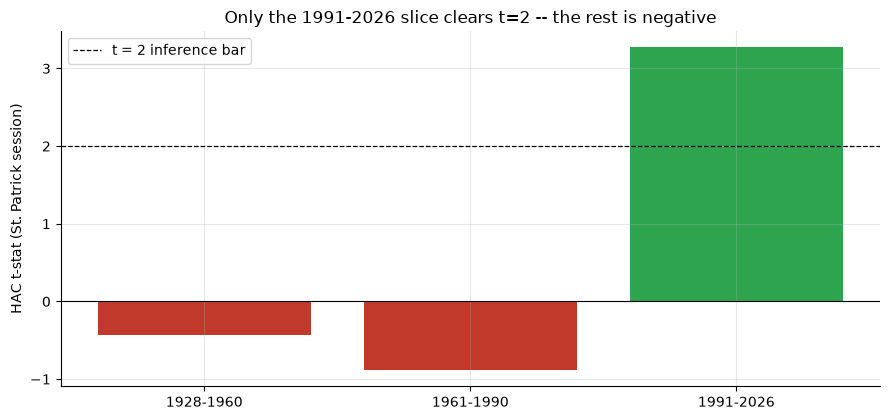

   period  n   mean_bps  tstat_hac
1928-1960 33  -9.940734  -0.427712
1961-1990 30 -12.210749  -0.886342
1991-2026 36  59.913838   3.270349

A single positive regime flanked by two negative ones = regime artifact.


In [4]:
if HAVE_REAL:
    sub = st.subperiod_table(df)
else:
    sub = pd.DataFrame([
        {'period': R['sub_a_lbl'], 'n': R['sub_a_n'], 'mean_bps': R['sub_a_bps'], 'tstat_hac': R['sub_a_t']},
        {'period': R['sub_b_lbl'], 'n': R['sub_b_n'], 'mean_bps': R['sub_b_bps'], 'tstat_hac': R['sub_b_t']},
        {'period': R['sub_c_lbl'], 'n': R['sub_c_n'], 'mean_bps': R['sub_c_bps'], 'tstat_hac': R['sub_c_t']},
    ])

fig, ax = plt.subplots(figsize=(9.0, 4.3))
colors = [GREEN if t >= 2 else AMBER if t >= 0 else RED for t in sub['tstat_hac']]
ax.bar(sub['period'], sub['tstat_hac'], color=colors)
ax.axhline(2.0, c='k', ls='--', lw=0.9, label='t = 2 inference bar')
ax.axhline(0, c='k', lw=0.8)
ax.set_ylabel('HAC t-stat (St. Patrick session)')
ax.set_title('Only the 1991-2026 slice clears t=2 -- the rest is negative')
ax.legend(); plt.tight_layout(); plt.show()
print(sub.to_string(index=False))
print()
print('A single positive regime flanked by two negative ones = regime artifact.')

## 5 - The verdict

- **Signal `NONE`** -- event mean +14.8 bps, HAC t = 1.13; vs other March days Welch p = 0.299. The effect is entirely a 1991-2026 phenomenon (t = 3.27) and *negative* in both prior regimes.
- **Tradability `MIRAGE`** -- one round-trip/yr, ~13 bps net, HAC t = 0.98; no vehicle beats holding the index.
- **Busted** -- the placebo is flat, nothing survives Bonferroni, and the sub-period split exposes the bump as a regime artifact.

## 6 - Could you trade it? -- the cost-aware P&L

Long the index only on the St. Patrick's session; charged a 2 bps round-trip.

In [5]:
if HAVE_REAL:
    pnl = st.strategy_pnl(df, one_way_bps=1.0)
    print(f"Gross: {pnl['gross_mean_bps']:+.1f} bps/event  HAC t = {pnl['gross_tstat_hac']:+.2f}")
    print(f"Net (2 bps round-trip): {pnl['net_mean_bps']:+.1f} bps/event  HAC t = {pnl['net_tstat_hac']:+.2f}")
    print(f"Buy-and-hold drift: {pnl['bah_daily_ann_pct']:+.1f}%/yr -- earned every day, not one.")
else:
    print(f"Net (2 bps round-trip): {R['net_mean_bps']:+.1f} bps/event  HAC t = {R['net_tstat_hac']:+.2f}")
print()
print('One day of exposure a year cannot compound into a portfolio. No trade.')

Gross: +14.8 bps/event  HAC t = +1.13
Net (2 bps round-trip): +12.8 bps/event  HAC t = +0.98
Buy-and-hold drift: +6.3%/yr -- earned every day, not one.

One day of exposure a year cannot compound into a portfolio. No trade.


> Net of costs the bump is ~13 bps for a single session and statistically zero (HAC t = 0.98). Buy-and-hold captures the market's drift on all ~250 trading days; the holiday trade captures it on one. There is nothing to harvest.

## 7 - Going further -- the synthetic positive control

Does the engine detect a St. Patrick bump *when one exists*? Plant one and sweep its size.

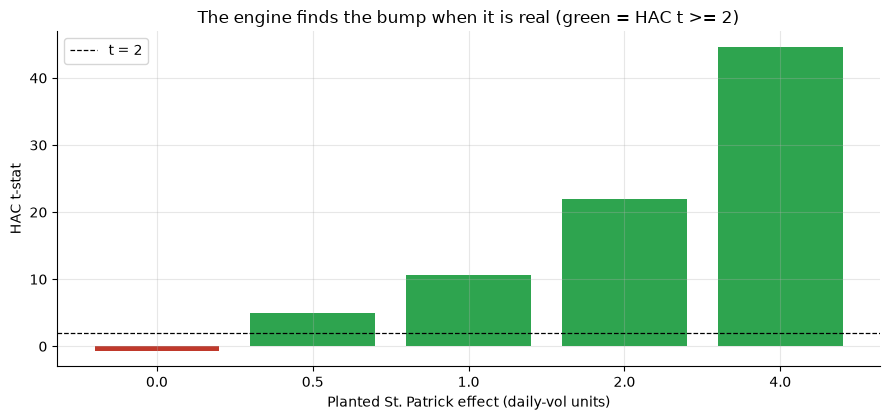

 effect   mean_bps     hac_t  welch_p_all
    0.0  -6.142565 -0.738099 3.027190e-01
    0.5  41.102994  4.938990 3.579399e-05
    1.0  88.348553 10.616078 6.353555e-16
    2.0 182.839672 21.970255 9.653087e-37
    4.0 371.821908 44.678608 1.735692e-63

Null (effect=0) reads ~0; a planted bump lights up. The real tape stays dark.


In [6]:
planted = [0.0, 0.5, 1.0, 2.0, 4.0]   # effect in daily-vol units
rows = []
for eff in planted:
    df_s, truth = data.synthetic_daily(n_years=99, stpat_effect=eff, seed=285)
    r = st.stpat_comparison(df_s)
    rows.append({'effect': eff, 'mean_bps': r['mean_stpat_bps'],
                 'hac_t': r['tstat_stpat_hac'], 'welch_p_all': r['pval_welch_all']})
res = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9.0, 4.3))
colors = [GREEN if t >= 2 else RED for t in res['hac_t']]
ax.bar([str(e) for e in res['effect']], res['hac_t'], color=colors)
ax.axhline(2.0, c='k', ls='--', lw=0.9, label='t = 2')
ax.set_xlabel('Planted St. Patrick effect (daily-vol units)')
ax.set_ylabel('HAC t-stat')
ax.set_title('The engine finds the bump when it is real (green = HAC t >= 2)')
ax.legend(); plt.tight_layout(); plt.show()
print(res.to_string(index=False))
print()
print('Null (effect=0) reads ~0; a planted bump lights up. The real tape stays dark.')

The engine correctly reads ~zero on the null and crosses t=2 once a real bump is planted. The real ^GSPC tape -- HAC t = 1.13, concentrated in one regime -- is nowhere near the detection threshold. The verdict is about the **data**, not the method.